# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Marit Bakelaar
* Username: mdbakelaar
* Student number: S6360912
* Group (AS1, etc.): As4

-----

In [1]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [16]:
import numpy as np
import sympy as sp
from scipy.integrate import quad

#make a class for all the different ways to solve an integral
class Integral:
    def __init__(self,func, a, b):
        self.a = a
        self.b = b
        self.func_str = func 
        self.func = lambda x: eval(func, {'np': np, 'sin': np.sin, 'cos': np.cos, 'tan': np.tan, 'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt, 'pi': np.pi, 'e': np.e, 'x': x})

    #make a def for the Trapezium integration method
    def Trapezium(self, n=500):
        x = np.linspace(self.a, self.b, n+1)
        y = self.func(x)
        h = (self.b - self.a)/n
        return h * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

    #make a def for the Simpson integration method
    def Simpson(self, n=500):
        if n % 2 != 0:
            raise ValueError("n must be even")

        h = (self.b - self.a) / n
        x = np.linspace(self.a, self.b, n + 1)
        y = self.func(x)

        S = h/3 * (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]))
        return S

    #make a def for the montecarlo integration method
    def Montecarlo(self, N=1000):
        x = np.random.uniform(self.a, self.b, N)
        return (self.b - self.a) * np.mean(self.func(x))

    #make a def for the scipy integration method
    def Scipy(self):
        result, error = quad(self.func, self.a, self.b)
        return result    

    #make a def for the sympy integration method
    def Sympy(self):
        x_sym = sp.Symbol('x')
        expr = sp.sympify(self.func_str, locals={'x': x_sym})
        result = sp.integrate(expr, (x_sym, self.a, self.b))
        return float(result)

#doing a test for the given function and bounds.
integrator = Integral('1 + x + sin(2*x)', 0.5, 3.0)
print("Trapezium:", integrator.Trapezium())
print("Simpson:", integrator.Simpson())
print("Monte Carlo:", integrator.Montecarlo())
print("SymPy:", integrator.Sympy())
print("SciPy:", integrator.Scipy())

Trapezium: 6.665067759061722
Simpson: 6.665066009597225
Monte Carlo: 6.685614092130909
SymPy: 6.665066009608887
SciPy: 6.6650660096088865


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

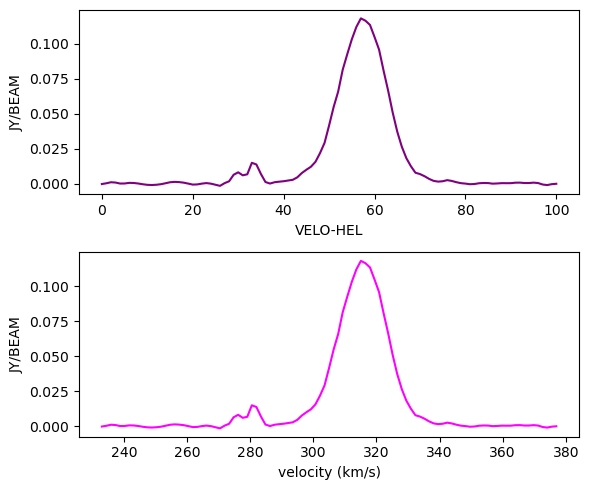

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

hdulist = fits.open("ngc6946.fits")
data = hdulist[0].data
header = hdulist[0].header

#taking a slice of the data that we need
dataslice = data[:, 55, 58]

#make the plots
fig, ax = plt.subplots(2,1,figsize=(6,5))
#plot the data slice
ax[0].plot(dataslice, color = 'purple')
#give labels to the axes
ax[0].set_xlabel(header['CTYPE3']) 
ax[0].set_ylabel(header['BUNIT'])

#making a linspace to define x with velocities from the data
v = np.linspace(233, 377, len(data[:, 55, 58]))
#plot the velocities against the given data
ax[1].plot(v, data[:, 55, 58], color = 'magenta') 
#giving the x axis a different label
ax[1].set_xlabel('velocity (km/s)') 
ax[1].set_ylabel(header['BUNIT']) 
plt.tight_layout()
plt.show()

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [19]:
from sympy import *

#the function
def f(x, amp, mu, sigma, zero):
    return amp * exp(-(x - mu)**2 / (2 * sigma**2)) + zero
    

In [7]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

In [20]:
from sympy import *

#make all the things used in the function something that sympy can actually work with and differentiate
x, amp, mu, sigma, zero = symbols('x amp mu sigma zero')

#the function
def f(x, amp, mu, sigma, zero):
    return amp * exp(-(x - mu)**2 / (2 * sigma**2)) + zero

#make a test function and get its derivative
test = f(x, amp, mu, sigma, zero)
der = diff(test, x) 

#print the function and the derivative
print(f"Function: {test}")
print(f"Derivative (y'): {der}")

#We can see that the derivative is not a constant, this means that the function is not linear, since then it would have been of the form y=ax which would have
#then become y'=a and that is not the case. 

Function: amp*exp(-(-mu + x)**2/(2*sigma**2)) + zero
Derivative (y'): -amp*(-2*mu + 2*x)*exp(-(-mu + x)**2/(2*sigma**2))/(2*sigma**2)


In [9]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

amp: 0.1169 +/- 0.0011
mu: 315.7168 +/- 0.0772
sigma: 7.2611 +/- 0.0817
zero: 0.0013 +/- 0.0003


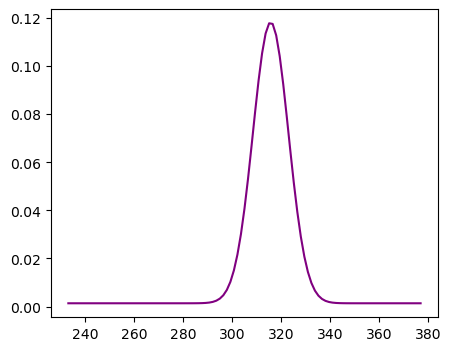

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def f(x, amp, mu, sigma, zero): #the definition
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) + zero

hdulist = fits.open("ngc6946.fits")
data = hdulist[0].data
header = hdulist[0].header

#x and y values
x = np.linspace(233, 377, len(data[:, 55, 58]))
y = data[:, 55, 58]

#gettign the amplitude from looking at the previous graph and taking this aprrox.
Amp = 0.10    
#here the same, looking where the aprroximate peak is. 
Mu = 320   
#taking 10% of the data as the deviation
Sigma = 15 
#takign a value thats not exactly zero but close.
Zero = 0.0005             
p0 = [Amp, Mu, Sigma, Zero]

#copypaste from notebook
beta, pcov = curve_fit(f, x, y, p0=p0) 
dbeta = np.sqrt(np.diag(pcov))

#print the offsets
labels = ['amp', 'mu', 'sigma', 'zero'] 
for i, name in enumerate(labels):
    print(f"{name}: {beta[i]:.4f} +/- {dbeta[i]:.4f}")
    
plt.figure(figsize=(5,4))

#plot the data
plt.plot(x, f(x, *beta), color = 'purple') 
plt.show()


In [11]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

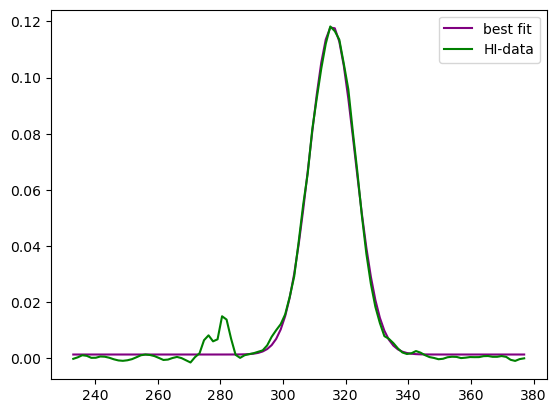

In [22]:
from matplotlib import pyplot as plt

hdulist = fits.open("ngc6946.fits")
data = hdulist[0].data
header = hdulist[0].header

x = np.linspace(233, 377, len(data[:, 55, 58]))
y = data[:, 55, 58]

fig, ax = plt.subplots()
ax.plot(x, f(x, *beta), color = 'purple', label = 'best fit')
ax.plot (x, y, color = 'green', label = 'HI-data')
ax.legend()
plt.show()

In [13]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

amp: 0.0121 +/- 0.0011
mu: 280.1245 +/- 0.0772
sigma: 3.3293 +/- 0.0817
zero: -0.0002 +/- 0.0003


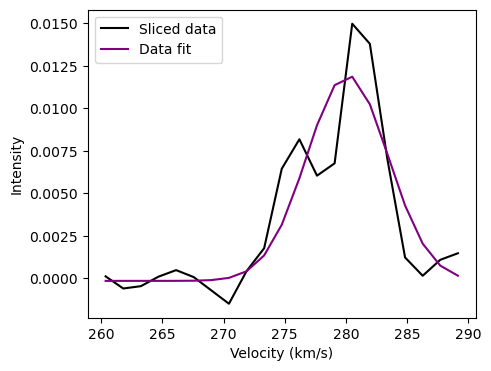

In [23]:
from sympy import *
import numpy as np
from scipy.optimize import curve_fit

def f(x, amp, mu, sigma, zero):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) + zero

x = np.linspace(233, 377, len(data[:, 55, 58]))
y = data[:, 55, 58]
#making a mask for the place we now want the data of
mask = (x > 260) & (x < 290) 
xmask = x[mask]
ymask = y[mask] 


#getting new approximations for these
Amp2 = 0.015    
Mu2 = 280   
Sigma2 = 3 
Zero2 = 0.001
p02 = [Amp2, Mu2, Sigma2, Zero2]

beta2, pcov2 = curve_fit(f, xmask, ymask, p0=p02) 
Beta2 = np.sqrt(np.diag(pcov))

#printing the values
labels = ['amp', 'mu', 'sigma', 'zero'] 
for i, name in enumerate(labels):
    print(f"{name}: {beta2[i]:.4f} +/- {Beta2[i]:.4f}")

#plotting
fig, ax = plt.subplots(figsize=(5,4))

# Plot the data points slice
ax.plot(xmask, ymask, color='black', label='Sliced data') 

# Plot the data fit for the small peak
ax.plot(xmask, f(xmask, *beta2), color='purple', label='Data fit') 

ax.set_xlabel('Velocity (km/s)')
ax.set_ylabel('Intensity')
ax.legend()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [24]:
#calculating the FWHM and the error
FWHMmain = 7.2611 * 2 * np.sqrt(2*np.log(2))
FWHMsmall = 3.3293 * 2 * np.sqrt(2*np.log(2))
errFm = 0.0817 * 2 * np.sqrt(2*np.log(2))
errFs = 0.0817 * 2 * np.sqrt(2*np.log(2))

#printing them
print(f"The FWHM of the main peak is: {FWHMmain :.2f} with an error of +/- {errFm: .2f}")
print(f"The FWHM of the small peak is: {FWHMsmall: .2f} with an error of +/- {errFs: .2f} ")



The FWHM of the main peak is: 17.10 with an error of +/-  0.19
The FWHM of the small peak is:  7.84 with an error of +/-  0.19 


In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

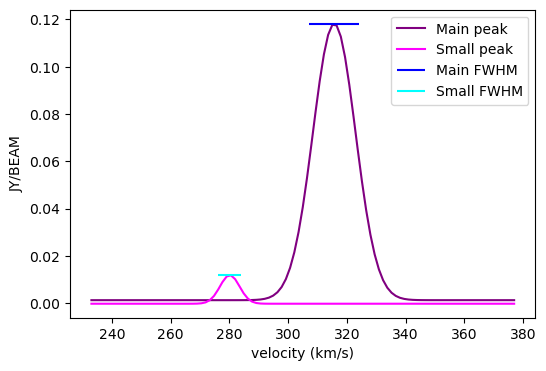

In [25]:
import numpy as np
import matplotlib.pyplot as plt

#fucntion
def f(x, amp, mu, sigma, zero): 
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) + zero

#The fucntion evaluated at the given points for the main and small peak
main = f(x,0.1169,315.7168,7.2611,0.0013)
small = f(x,0.0121,280.1245,3.3293,-0.0002)

#calculating the main and small FWHM
mainFWHM = 2*7.2611*sqrt(2*np.log(2))
smallFWHM = 2*3.3293*sqrt(2*np.log(2))

#the height of both peaks
heightmain = 0.1169 + 0.0013
heightsmall = 0.0121 - 0.0002

#setting up the data for the correct bar at the peaks
leftmain = 315.7168 - (mainFWHM / 2)
rightmain = 315.7168 + (mainFWHM / 2)

leftsmall = 280.1245 - (smallFWHM / 2)
rightsmall = 280.1245 + (smallFWHM / 2)

#plotting the figure and the given values
plt.figure(figsize=(6,4))
plt.plot(x, main, color='purple', label= 'Main peak')
plt.plot(x, small, color='magenta', label='Small peak')
plt.hlines(y=heightmain, xmin=leftmain, xmax=rightmain, color='blue', label=f'Main FWHM')
plt.hlines(y=heightsmall, xmin=leftsmall, xmax=rightsmall, color='cyan', label=f'Small FWHM')
plt.xlabel('velocity (km/s)')
plt.ylabel(header['BUNIT']) 
plt.legend()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   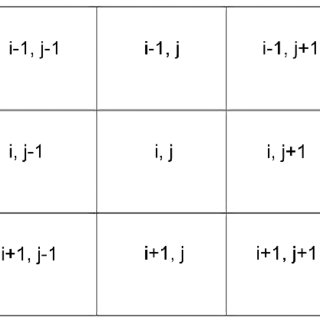    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

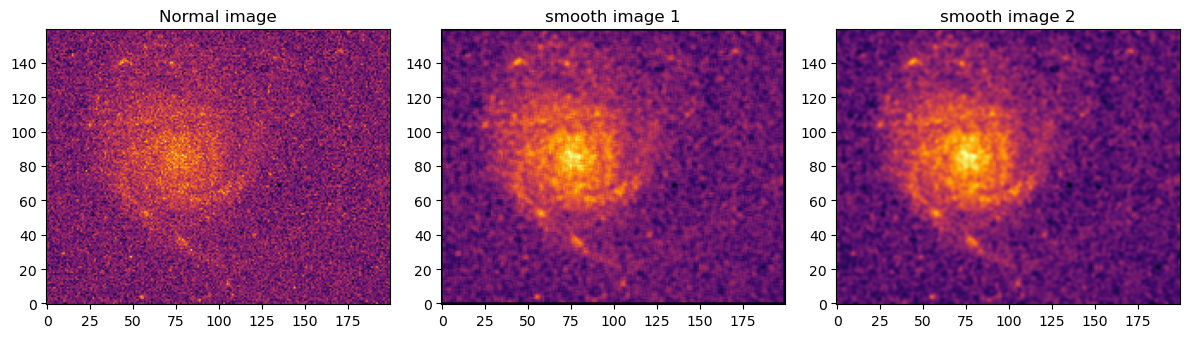

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.pyplot import figure
from scipy import ndimage

#The function to smooth it out
def smooth(M): 
    rows, cols = M.shape 
    Mc = np.zeros((rows, cols)) 
    #code to smooth out multiple pixels into 1 pixel so the entire image gets smoothed out.
    for i in range(1, rows - 1): 
        for j in range(1, cols - 1):
            around = M[i-1 : i+2, j-1 : j+2] 
            Mc[i, j] = np.mean(around) 
    return Mc

#using the given function from abovve
def smooth2(M):
    Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
    return Mc

#openeing the data file
galaxy = fits.open("faintgalaxy.fits")
M = galaxy[0].data 

#plug the M into the 2 functions
Mc1 = smooth(M)
Mc2 = smooth2(M)

#setting up the frames in which the different smoothed out images can be in
fig = figure(figsize=(12, 4)) 
frame1 = fig.add_subplot(1, 3, 1)
frame2 = fig.add_subplot(1, 3, 2)
frame3 = fig.add_subplot(1, 3, 3) 

#plot the images
frame1.imshow(M, origin='lower', cmap = 'inferno')
frame1.set_title("Normal image") 
frame2.imshow(Mc1, origin='lower', cmap = 'inferno')
frame2.set_title("smooth image 1")
frame3.imshow(Mc2, origin='lower', cmap = 'inferno')
frame3.set_title("smooth image 2")
plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")